# SPY Next-Day Direction Prediction

**GCSRM Recruitment 2026 -- Technical Track: AI & Machine Learning (Year 2), Option A: Stock Price Movement Predictor**

A time-series classification experiment: predict whether SPY (SPDR S&P 500 ETF) will close **Up** or **Down** tomorrow,
using only information available today. The focus is methodological rigor -- zero temporal data leakage, honest
naive baselines, a strict chronological evaluation -- over chasing a high accuracy number.

## 2. Objective

1. Engineer same-day (raw) and technical-indicator (engineered) features from daily OHLCV data, **without any
   forward-looking information**.
2. Establish two naive baselines -- **Persistence** and **Majority Class** -- that any real model must beat to be
   considered useful.
3. Compare **raw features** vs **raw + engineered indicator features** under an identical linear model, to see
   whether technical-indicator engineering actually helps.
4. Evaluate everything with a **strict chronological split** (no shuffling) plus a **walk-forward** check, and
   report results honestly -- including if the model barely beats, or fails to beat, the naive baselines.

## 3. Dataset

- **Ticker:** SPY (SPDR S&P 500 ETF Trust) -- tracks the S&P 500 index.
- **Why SPY qualifies as liquid:** SPY is consistently one of the highest-volume, highest-AUM ETFs traded on any
  US exchange (tens of millions of shares/day), so its price series is clean, continuously traded, and free of the
  thin-liquidity artifacts (stale prices, wide bid/ask-driven noise) that would contaminate a small-cap or illiquid ticker.
- **Source:** Yahoo Finance, via the `yfinance` Python package (free, scriptable, reproducible by anyone re-running
  this notebook).
- **Range:** 2005-01-01 through 2025-12-31 inclusive (`yfinance`'s `end` is exclusive, so `download_data()` passes
  `end="2026-01-01"`).
- **Columns:** `Open`, `High`, `Low`, `Close`, `Volume` -- standard daily OHLCV. `auto_adjust=True` is set explicitly
  so `Close` is split/dividend-adjusted.
- The data is downloaded **once** via `src/data.py::download_data()` and committed to `data/spy_daily.csv`. This
  notebook only ever *loads* that CSV (`load_data()`), so re-running the notebook never silently changes the dataset.

## 4. Data Loading

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src.data import load_data, DATA_PATH

pd.set_option("display.width", 120)
print(f"Loading from: {DATA_PATH}")

df = load_data()
print(f"Rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

Loading from: D:\PROJECTS\Stock-ml\data\spy_daily.csv
Rows: 5283
Date range: 2005-01-03 to 2025-12-31


,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03,82.024810,82.159767,80.904698,81.174606,55748000
2005-01-04,81.282587,81.336570,79.919557,80.182716,69167600
2005-01-05,80.121949,80.466083,79.622623,79.629372,65667300
2005-01-06,79.919547,80.398631,79.798088,80.034256,47814700
2005-01-07,80.277159,80.452600,79.710351,79.919533,55847700


In [2]:
df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2025-12-24,684.313382,687.178163,684.164151,686.730530,39445600
2025-12-26,686.989161,688.003728,685.626408,686.660889,41613300
2025-12-29,683.905508,685.556767,682.443308,684.213867,62559500
2025-12-30,683.815972,684.920090,682.950576,683.378296,47160700
2025-12-31,683.507684,683.726492,678.106396,678.315247,74144800


## 5. Data Cleaning

`load_data()` already validated the following on load (see `src/data.py`) -- if any of these failed, the assertions
inside `load_data()` would have raised and the cell above would not have completed:

- Dates are sorted ascending, with no duplicates.
- No missing values anywhere in `Open, High, Low, Close, Volume`.
- No zero or negative prices, no zero or negative volume.

So the dataset loaded above is already clean. A quick structural check below confirms it.

In [3]:
print("dtypes:")
print(df.dtypes)
print()
print("Any NaNs:", df.isna().any().any())
print("Any non-positive prices:", (df[["Open", "High", "Low", "Close"]] <= 0).any().any())
print("Any non-positive volume:", (df["Volume"] <= 0).any())
print("Index sorted ascending, no duplicates:", df.index.is_monotonic_increasing and not df.index.duplicated().any())
df.describe()

dtypes:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Any NaNs: False
Any non-positive prices: False
Any non-positive volume: False
Index sorted ascending, no duplicates: True


,Open,High,Low,Close,Volume
count,5283.000000,5283.000000,5283.000000,5283.000000,5.283000e+03
mean,224.339915,225.577693,222.985269,224.370989,1.231102e+08
std,155.862011,156.627582,155.005285,155.890549,9.010261e+07
min,49.563867,51.059174,48.943877,49.680576,1.527000e+07
25%,97.996777,98.539971,97.330299,97.970966,6.520655e+07
50%,170.662547,171.527923,169.972211,170.719238,9.225830e+07
75%,314.211579,315.706630,310.764827,313.092377,1.510066e+08
max,686.989161,688.003728,685.626408,686.730530,8.710263e+08


## 6. Exploratory Data Analysis

A look at the full 21-year price history, and the daily return distribution, before any feature engineering.

In [4]:
import io
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image


def show_fig(fig):
    """Render a matplotlib figure inline without depending on a live GUI/inline backend."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image(data=buf.read())

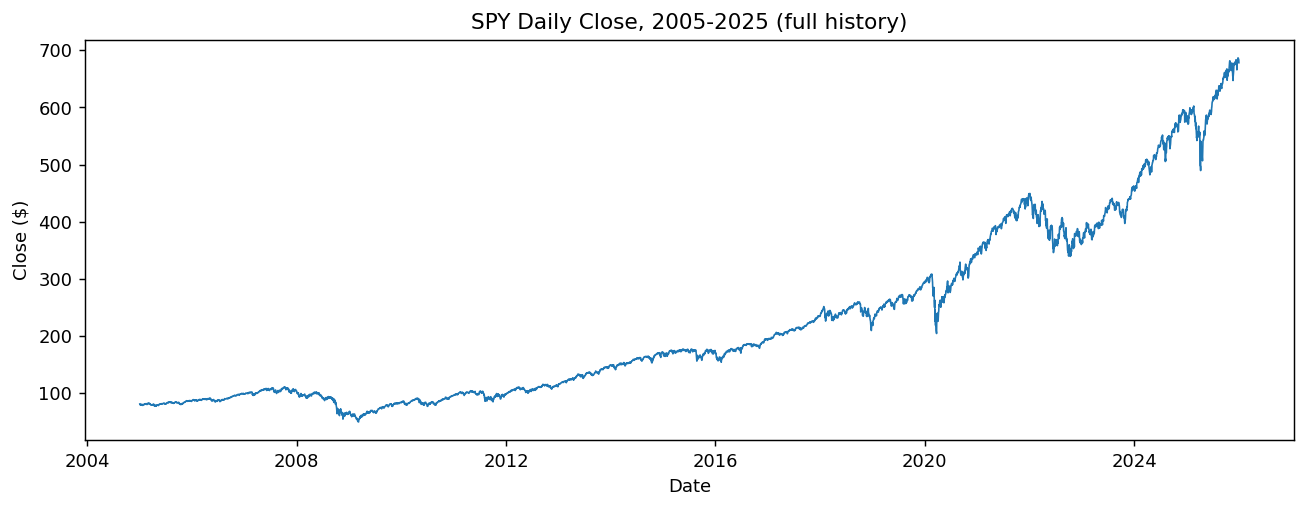

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["Close"], color="#1f77b4", linewidth=0.9)
ax.set_title("SPY Daily Close, 2005-2025 (full history)")
ax.set_xlabel("Date")
ax.set_ylabel("Close ($)")
show_fig(fig)

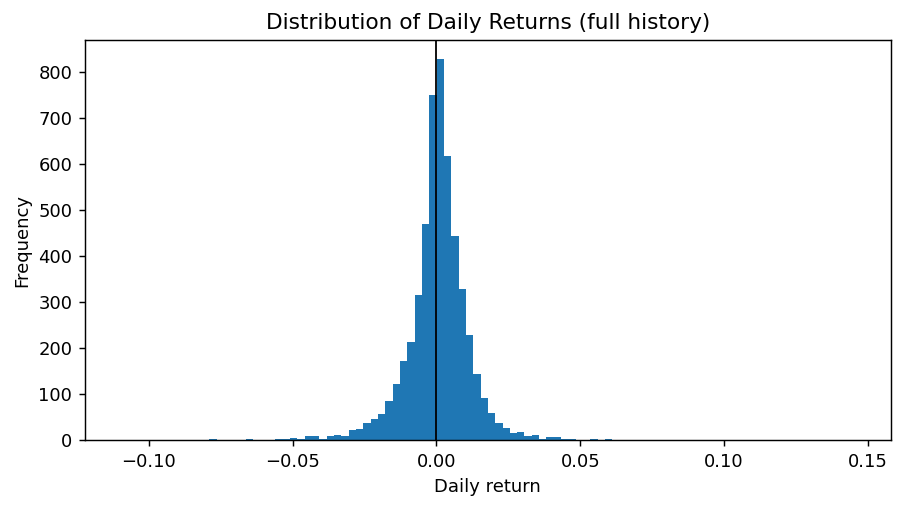

In [6]:
daily_ret = df["Close"].pct_change().dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(daily_ret, bins=100, color="#1f77b4")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Distribution of Daily Returns (full history)")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
show_fig(fig)

In [7]:
print(f"Mean daily return: {daily_ret.mean():.5f}")
print(f"Std daily return:  {daily_ret.std():.5f}")
print(f"% up days (Close_t > Close_t-1): {(daily_ret > 0).mean():.4f}")

Mean daily return: 0.00047
Std daily return:  0.01200
% up days (Close_t > Close_t-1): 0.5515


## 7. Target Construction

The target represents **tomorrow's direction relative to today's close**:

```
next_close = Close shifted by -1 (one row into the future)
target = 1 if next_close > Close else 0   (Up = 1, Down = 0; ties count as Down)
```

The last row of the dataset has no known next-day close (there is no "tomorrow" in the data). The critical
implementation detail: **that row must be dropped BEFORE casting to int**, not after. If it were cast first,
`NaN > x` would evaluate to `False`, then `astype(int)` would silently turn that into a **fake `0` (Down) label** --
a real, easy-to-introduce leakage/correctness bug. The code below drops it first and asserts that exactly one row
was dropped and that it is in fact the last row.

This logic is written here inline (per the project plan) rather than only called from `src/features.py`, so the
construction is fully visible. It is then cross-checked against `src/features.py::build_target`, which implements
the same logic and is what the rest of the pipeline actually uses.

In [8]:
next_close = df["Close"].shift(-1)
valid = next_close.notna()

n_dropped = int((~valid).sum())
assert n_dropped == 1, f"Expected exactly 1 undefined-target row, got {n_dropped}"
assert df.index[~valid][0] == df.index[-1], "The dropped row must be the last row"

close_valid = df["Close"][valid]
next_close_valid = next_close[valid]
target = (next_close_valid > close_valid).astype(int)
target.name = "target"

print(f"df has {len(df)} rows; target has {len(target)} rows (dropped exactly {n_dropped})")
print(f"Last date in df:      {df.index[-1].date()}")
print(f"Last date in target:  {target.index[-1].date()}  (one day earlier, as expected)")

df has 5283 rows; target has 5282 rows (dropped exactly 1)
Last date in df:      2025-12-31
Last date in target:  2025-12-30  (one day earlier, as expected)


In [9]:
# Cross-check against src/features.py::build_target (the version the rest of the pipeline uses)
from src.features import build_target

target_src = build_target(df)
assert target.equals(target_src), "Inline target construction disagrees with src.features.build_target"
print("Inline target construction matches src.features.build_target exactly. PASS")

Inline target construction matches src.features.build_target exactly. PASS


## 8. Explicit Leakage Verification

Three checks, all shown inline:

1. A `Date | Close_t | Close_t+1 | Target` table (first 5 rows, last 5 rows) -- to visually confirm the target is
   built from *tomorrow's* close relative to *today's*, and that the final row correctly has no label.
2. A **truncation test**: recompute features on data cut off at several dates `d`. If any feature used information
   from *after* `d`, truncating the data at `d` would change that feature's value at `d`. It must not.
3. Confirmation (already shown in Section 7) that the undefined last-row label was dropped, never faked as `0`.

In [10]:
leak_table = pd.DataFrame({
    "Close_t": df["Close"],
    "Close_t+1": df["Close"].shift(-1),
    "Target": target.reindex(df.index),  # NaN on the last row by construction
})
print("First 5 rows:")
print(leak_table.head())
print("\nLast 5 rows (last row's Close_t+1 / Target are NaN -- correctly excluded, not faked):")
print(leak_table.tail())

First 5 rows:
              Close_t  Close_t+1  Target
Date                                    
2005-01-03  81.174606  80.182716     0.0
2005-01-04  80.182716  79.629372     0.0
2005-01-05  79.629372  80.034256     1.0
2005-01-06  80.034256  79.919533     0.0
2005-01-07  79.919533  80.297409     1.0

Last 5 rows (last row's Close_t+1 / Target are NaN -- correctly excluded, not faked):
               Close_t   Close_t+1  Target
Date                                      
2025-12-24  686.730530  686.660889     0.0
2025-12-26  686.660889  684.213867     0.0
2025-12-29  684.213867  683.378296     0.0
2025-12-30  683.378296  678.315247     0.0
2025-12-31  678.315247         NaN     NaN


In [11]:
# Manual recomputation of target from the table above must match target exactly
manual = (leak_table["Close_t+1"] > leak_table["Close_t"]).astype(int)
manual_valid = manual.iloc[:-1]  # drop the undefined last row to compare
assert (manual_valid.values == target.values).all()
print("Manual (Close_t+1 > Close_t) recomputation from the table matches target exactly. PASS")

Manual (Close_t+1 > Close_t) recomputation from the table matches target exactly. PASS


In [12]:
from src.features import build_raw_features, build_indicators

raw_full = build_raw_features(df)
ind_full = build_indicators(df, raw_full)
features_full = pd.concat([raw_full, ind_full], axis=1)

test_dates = df.index[[200, 1000, 2500, 4000, 5000]]  # spread across the series, well past warm-up
print("Truncation test -- features at date d recomputed on data cut off AT d must equal full-data features at d:\n")
for d in test_dates:
    df_trunc = df.loc[:d]
    raw_t = build_raw_features(df_trunc)
    ind_t = build_indicators(df_trunc, raw_t)
    feat_t = pd.concat([raw_t, ind_t], axis=1)

    ok = feat_t.loc[d].equals(features_full.loc[d])
    print(f"  {d.date()}: truncated == full-data  ->  {ok}")
    assert ok, f"LEAKAGE: features at {d} depend on data after {d}"

print(f"\nAll {len(test_dates)} truncation checks PASS -- no feature uses information from after its own date.")

Truncation test -- features at date d recomputed on data cut off AT d must equal full-data features at d:

  2005-10-18: truncated == full-data  ->  True
  2008-12-22: truncated == full-data  ->  True
  2014-12-08: truncated == full-data  ->  True
  2020-11-20: truncated == full-data  ->  True
  2024-11-13: truncated == full-data  ->  True

All 5 truncation checks PASS -- no feature uses information from after its own date.


## 9. Class Balance

Before building any model, it's worth knowing the base rate: how often is SPY actually Up vs Down the next day,
across the full usable target series? This number is exactly what the **Majority Class baseline** will exploit,
and it's why that baseline is a meaningful bar to clear (not a strawman).

(The official `class_balance.csv` / `class_balance.png` deliverables, broken down by train/test partition, are
generated in Section 12 after the chronological split -- this is the full-series view.)

In [13]:
up = int((target == 1).sum())
down = int((target == 0).sum())
n = len(target)
print(f"Full target series: {n} rows")
print(f"Up:   {up} ({up/n:.4%})")
print(f"Down: {down} ({down/n:.4%})")

Full target series: 5282 rows
Up:   2913 (55.1496%)
Down: 2369 (44.8504%)


## 10. Raw Feature Construction

"Raw" features are single-day, scale-free transforms of OHLCV -- no multi-day windows, no lookback beyond `t-1`:

| Feature | Formula | Meaning |
|---|---|---|
| `ret_1d` | `Close_t / Close_{t-1} - 1` | today's return |
| `range` | `(High - Low) / Close` | today's intraday range, normalized |
| `body` | `(Close - Open) / Open` | today's candle body, normalized |
| `gap` | `Open_t / Close_{t-1} - 1` | overnight gap |
| `vol_chg` | `log(Volume_t / Volume_{t-1})` | volume change |

All of these use only `shift(+1)` (past) or the current row's own OHLC -- never the target's `shift(-1)`.

In [14]:
raw_features = build_raw_features(df)
raw_features.head(10)

,ret_1d,range,body,gap,vol_chg
Date,,,,,
2005-01-03,NaN,0.015461,-0.010365,NaN,NaN
2005-01-04,-0.012219,0.017672,-0.013531,0.001330,0.215691
2005-01-05,-0.006901,0.010592,-0.006148,-0.000758,-0.051931
2005-01-06,0.005085,0.007504,0.001435,0.003644,-0.317268
2005-01-07,-0.001433,0.009287,-0.004455,0.003035,0.155295
2005-01-10,0.004728,0.009412,0.005577,-0.000844,0.012732
2005-01-11,-0.006891,0.006346,-0.003877,-0.003025,0.109356
2005-01-12,0.003300,0.011133,0.001436,0.001862,0.141907
2005-01-13,-0.008012,0.010457,-0.008597,0.000590,-0.269565


## 11. Technical Indicator Engineering

Five indicators were chosen to cover distinct, complementary signals rather than five variations on the same idea --
momentum, trend, mean-reversion/volatility positioning, medium-term trend distance, and volatility regime:

| Indicator | What it captures | Implementation |
|---|---|---|
| `rsi_14` | Momentum / overbought-oversold | Wilder's RSI(14), `ewm(alpha=1/14, adjust=False, min_periods=14)` on gains/losses |
| `macd_hist_norm` | Trend momentum | `(EMA12 - EMA26) - signal(9)`, normalized by Close; all EMAs `adjust=False` |
| `bb_pctb` | Mean-reversion / volatility positioning | Bollinger %B: `(Close - lower) / (upper - lower)`, SMA20 +/- 2*std20 |
| `dist_sma50` | Medium-term trend | `Close / SMA50 - 1` |
| `vol_20` | Realized volatility regime | rolling 20-day std of `ret_1d` |

All windows are trailing (`min_periods` set explicitly, never `center=True`, never `bfill`) -- so every indicator at
row `t` uses only data up to and including `t`. This was already verified by the truncation test in Section 8.

The feature list is **frozen** here: raw (5) + indicators (5) = 10 engineered features, decided in `PLAN.md` before
any test-set result was seen.

In [15]:
indicators = build_indicators(df, raw_features)
indicators.head(10)

,rsi_14,macd_hist_norm,bb_pctb,dist_sma50,vol_20
Date,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN
2005-01-04,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN
2005-01-10,NaN,NaN,NaN,NaN,NaN
2005-01-11,NaN,NaN,NaN,NaN,NaN
2005-01-12,NaN,NaN,NaN,NaN,NaN
2005-01-13,NaN,NaN,NaN,NaN,NaN


In [16]:
from src.features import build_dataset, RAW_FEATURE_COLUMNS, ENGINEERED_FEATURE_COLUMNS

X_raw, X_eng, y = build_dataset(df)

print(f"X_raw shape:        {X_raw.shape}   columns: {list(X_raw.columns)}")
print(f"X_engineered shape: {X_eng.shape}   columns: {list(X_eng.columns)}")
print(f"y shape:            {y.shape}")
print()
print("Same row index across X_raw / X_eng / y:", X_raw.index.equals(X_eng.index) and X_raw.index.equals(y.index))
print(f"Usable date range after dropping warm-up NaNs: {X_eng.index.min().date()} to {X_eng.index.max().date()}")
print(f"NaNs remaining: X_raw={X_raw.isna().sum().sum()}, X_eng={X_eng.isna().sum().sum()}, y={y.isna().sum()}")

X_raw shape:        (5233, 5)   columns: ['ret_1d', 'range', 'body', 'gap', 'vol_chg']
X_engineered shape: (5233, 10)   columns: ['ret_1d', 'range', 'body', 'gap', 'vol_chg', 'rsi_14', 'macd_hist_norm', 'bb_pctb', 'dist_sma50', 'vol_20']
y shape:            (5233,)

Same row index across X_raw / X_eng / y: True
Usable date range after dropping warm-up NaNs: 2005-03-15 to 2025-12-30
NaNs remaining: X_raw=0, X_eng=0, y=0


In [17]:
# X_raw and X_eng are evaluated on the SAME rows -- confirmed above -- so the raw-vs-engineered
# comparison later isn't confounded by different row sets (e.g. different warm-up lengths).
X_eng.head()

,ret_1d,range,body,gap,vol_chg,rsi_14,macd_hist_norm,bb_pctb,dist_sma50,vol_20
Date,,,,,,,,,,
2005-03-15,-0.008255,0.011487,-0.010542,0.002311,0.541362,44.620192,-0.001419,0.303212,0.004807,0.007318
2005-03-16,-0.008490,0.010578,-0.004845,-0.003663,0.181627,40.139987,-0.002335,0.105078,-0.003527,0.007481
2005-03-17,0.002015,0.006367,0.000419,0.001595,-0.179297,41.625397,-0.002681,0.194209,-0.001608,0.007501
2005-03-18,-0.002969,0.011642,-0.004785,0.001825,-0.038309,40.045466,-0.002987,0.148180,-0.004738,0.007323
2005-03-21,-0.003712,0.008637,-0.005139,0.001434,0.016667,38.103966,-0.003290,0.104452,-0.008425,0.007344


## 12. Chronological Train/Test Split

A strict **80/20 chronological split** -- no shuffling, ever. The training period is always strictly earlier than
the test period.

**1-row embargo:** the label at the last training row is `1 if Close_{first_test_day} > Close_{last_train_day} else 0`
-- i.e. it is derived from the *first test day's* closing price. Leaving it in the training set would let the model
train on a label that encodes test-period information. So that one row is dropped entirely (used in neither train
nor test) after the raw 80/20 cut.

In [18]:
from src.evaluation import chronological_split

X_raw_train, X_raw_test, y_train, y_test = chronological_split(X_raw, y, test_frac=0.2)
X_eng_train, X_eng_test, y_train_eng, y_test_eng = chronological_split(X_eng, y, test_frac=0.2)

assert X_raw_test.index.equals(X_eng_test.index) and y_test.equals(y_test_eng)
assert X_raw_train.index.max() < X_raw_test.index.min()

print(f"n_train = {len(y_train)}   n_test = {len(y_test)}")
print(f"Train dates: {X_raw_train.index.min().date()} -> {X_raw_train.index.max().date()}")
print(f"Test dates:  {X_raw_test.index.min().date()} -> {X_raw_test.index.max().date()}")
print(f"Embargoed (dropped) date range: between {X_raw_train.index.max().date()} and {X_raw_test.index.min().date()}")
print(f"\nAssertion max(train dates) < min(test dates): {X_raw_train.index.max() < X_raw_test.index.min()}")

n_train = 4185   n_test = 1047
Train dates: 2005-03-15 -> 2021-10-26
Test dates:  2021-10-28 -> 2025-12-30
Embargoed (dropped) date range: between 2021-10-26 and 2021-10-28

Assertion max(train dates) < min(test dates): True


             up  down     n    pct_up  pct_down
partition                                      
full       2886  2347  5233  0.551500  0.448500
train      2319  1866  4185  0.554122  0.445878
test        566   481  1047  0.540592  0.459408

Saved -> D:\PROJECTS\Stock-ml\outputs\class_balance.csv


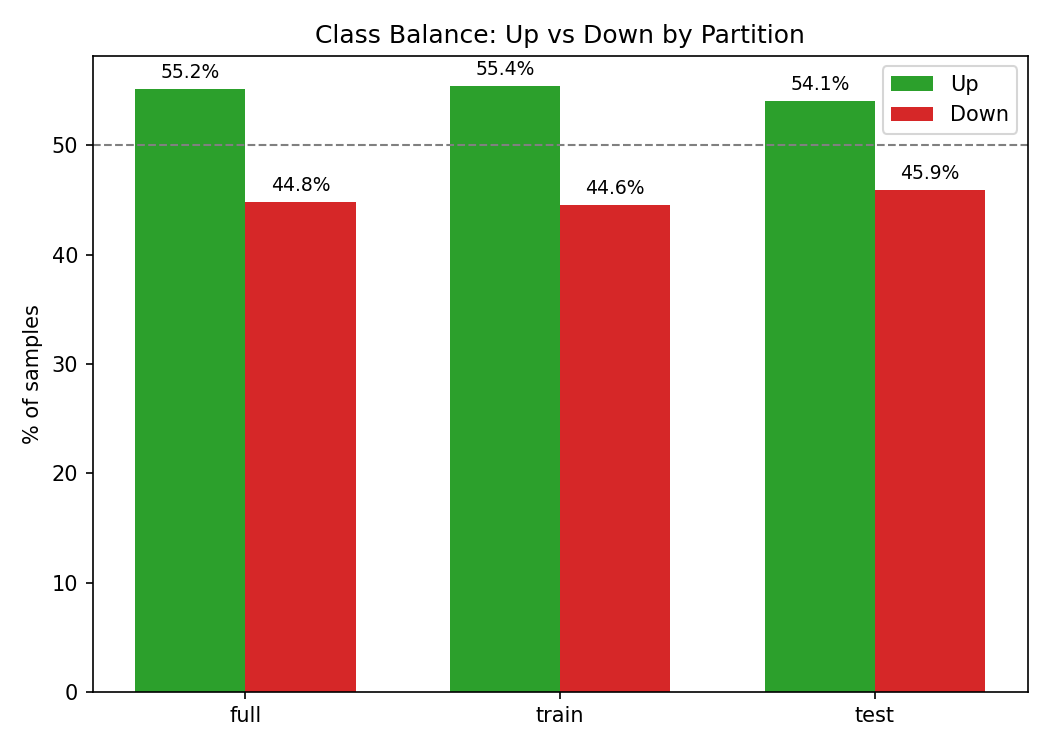

In [19]:
from src.evaluation import class_balance_report, plot_class_balance
from src.evaluation import OUTPUTS_DIR

balance = class_balance_report(y, y_train, y_test)
balance.to_csv(OUTPUTS_DIR / "class_balance.csv")
print(balance)
print(f"\nSaved -> {OUTPUTS_DIR / 'class_balance.csv'}")

balance_png_path = plot_class_balance(balance)
show_fig_path = balance_png_path
from IPython.display import Image as _Image
_Image(filename=str(balance_png_path))

## 13. Persistence Baseline

Predict that tomorrow's direction equals today's direction: `Close_t > Close_{t-1}`. This is exactly the sign of
`ret_1d`, which is already a same-day (no future information) feature -- so no fitting is required, it's a fixed
rule applied directly to the test set.

In [20]:
from src.models import persistence_predict
from src.evaluation import compute_metrics

pred_persistence = persistence_predict(X_raw_test)
metrics_persistence = compute_metrics(y_test, pred_persistence)
metrics_persistence

{'accuracy': 0.5100286532951289,
 'accuracy_ci_low': np.float64(0.479748548101878),
 'accuracy_ci_high': np.float64(0.5403087584883798),
 'balanced_accuracy': 0.5066998229542399,
 'pct_predicted_up': 0.5415472779369628,
 'tn': 224,
 'fp': 257,
 'fn': 256,
 'tp': 310,
 'n': 1047}

## 14. Majority Class Baseline

Always predict the most common label in the **training** data (never peeking at test labels).

In [21]:
from src.models import majority_predict

pred_majority = majority_predict(y_train, y_test.index)
metrics_majority = compute_metrics(y_test, pred_majority)
print(f"Majority class in training data: {int(y_train.mode().iloc[0])}")
metrics_majority

Majority class in training data: 1


{'accuracy': 0.5405921680993314,
 'accuracy_ci_low': np.float64(0.5104059418866373),
 'accuracy_ci_high': np.float64(0.5707783943120255),
 'balanced_accuracy': 0.5,
 'pct_predicted_up': 1.0,
 'tn': 0,
 'fp': 481,
 'fn': 0,
 'tp': 566,
 'n': 1047}

## 15. Raw Feature Model

`StandardScaler -> LogisticRegression(C=1.0, max_iter=1000)`, fit **only** on the raw 5 features, with no
hyperparameter tuning. The scaler is part of the pipeline, so it is fit on training data only.

In [22]:
from src.models import fit_predict

pred_raw, pipe_raw = fit_predict(X_raw_train, y_train, X_raw_test)
metrics_raw = compute_metrics(y_test, pred_raw)
metrics_raw

{'accuracy': 0.5434574976122254,
 'accuracy_ci_low': np.float64(0.5132859109104962),
 'accuracy_ci_high': np.float64(0.5736290843139545),
 'balanced_accuracy': 0.5038990471852662,
 'pct_predicted_up': 0.9875835721107927,
 'tn': 8,
 'fp': 473,
 'fn': 5,
 'tp': 561,
 'n': 1047}

## 16. Engineered Feature Model

The **identical** pipeline (same `C=1.0`, same `max_iter`, no tuning), now fit on raw + the 5 technical indicators
(10 features total). The only difference from Section 15 is the feature set -- this isolates the effect of
technical-indicator engineering.

In [23]:
pred_engineered, pipe_engineered = fit_predict(X_eng_train, y_train, X_eng_test)
metrics_engineered = compute_metrics(y_test, pred_engineered)
metrics_engineered

{'accuracy': 0.5482330468003821,
 'accuracy_ci_low': np.float64(0.5180880956057112),
 'accuracy_ci_high': np.float64(0.578377997995053),
 'balanced_accuracy': 0.5090965523827715,
 'pct_predicted_up': 0.9828080229226361,
 'tn': 13,
 'fp': 468,
 'fn': 5,
 'tp': 561,
 'n': 1047}

In [24]:
# Further leakage verification: the fitted scaler's mean_ must equal the TRAIN feature mean,
# and must differ from the FULL-dataset feature mean (i.e. it was never fit on test data).
scaler_mean = pipe_engineered.named_steps["scaler"].mean_
train_mean = X_eng_train.mean().values
full_mean = X_eng.mean().values

matches_train = np.allclose(scaler_mean, train_mean)
differs_from_full = not np.allclose(scaler_mean, full_mean)
print("Scaler mean_ matches TRAIN feature mean (not full-data mean):", matches_train)
print("Scaler mean_ differs from FULL-data feature mean:", differs_from_full)
assert matches_train and differs_from_full
print("\nPASS -- StandardScaler was fit on training data only.")

Scaler mean_ matches TRAIN feature mean (not full-data mean): True
Scaler mean_ differs from FULL-data feature mean: True

PASS -- StandardScaler was fit on training data only.


## 17. Results Comparison

### 17.1 Single chronological 80/20 split

The four-way comparison table, plus a 95% confidence interval (normal approximation) for each accuracy, so that
differences between approaches can be judged against their statistical noise.

In [25]:
results = {
    "Persistence": metrics_persistence,
    "Majority Class": metrics_majority,
    "Raw Features": metrics_raw,
    "Engineered Features": metrics_engineered,
}
comparison_table = pd.DataFrame(results).T
comparison_table.index.name = "approach"
comparison_table.to_csv(OUTPUTS_DIR / "comparison_table.csv")
print(f"Saved -> {OUTPUTS_DIR / 'comparison_table.csv'}")
comparison_table

Saved -> D:\PROJECTS\Stock-ml\outputs\comparison_table.csv


,accuracy,accuracy_ci_low,accuracy_ci_high,balanced_accuracy,pct_predicted_up,tn,fp,fn,tp,n
approach,,,,,,,,,,
Persistence,0.510029,0.479749,0.540309,0.506700,0.541547,224.0,257.0,256.0,310.0,1047.0
Majority Class,0.540592,0.510406,0.570778,0.500000,1.000000,0.0,481.0,0.0,566.0,1047.0
Raw Features,0.543457,0.513286,0.573629,0.503899,0.987584,8.0,473.0,5.0,561.0,1047.0
Engineered Features,0.548233,0.518088,0.578378,0.509097,0.982808,13.0,468.0,5.0,561.0,1047.0


### 17.2 Walk-forward validation (generalization check)

The assignment asks us to "verify generalization under cross-session real-world constraints." We interpret this as
a **walk-forward validation**: `TimeSeriesSplit(n_splits=5, gap=1)` with an **expanding training window** (fold 1
trains on the earliest ~1/6 of the data, fold 5 trains on nearly all of it before its own test slice), `gap=1`
embargoing one row between each fold's train and test, and **Majority Class recomputed independently within each
fold's training data** (never reusing the single-split majority label). All 4 approaches are re-evaluated per fold,
and we report the mean +/- std of accuracy across folds.

In [26]:
from src.evaluation import walk_forward_evaluate

walk_forward_results = walk_forward_evaluate(X_raw, X_eng, y, n_splits=5, gap=1)
walk_forward_results.to_csv(OUTPUTS_DIR / "walk_forward_results.csv", index=False)
print(f"Saved -> {OUTPUTS_DIR / 'walk_forward_results.csv'}")
walk_forward_results

Saved -> D:\PROJECTS\Stock-ml\outputs\walk_forward_results.csv


,fold,approach,accuracy,n_train,n_test
0,1,Persistence,0.508028,872,872
1,1,Majority Class,0.555046,872,872
2,1,Raw Features,0.524083,872,872
3,1,Engineered Features,0.526376,872,872
4,2,Persistence,0.498853,1744,872
5,2,Majority Class,0.556193,1744,872
6,2,Raw Features,0.556193,1744,872
7,2,Engineered Features,0.557339,1744,872
8,3,Persistence,0.473624,2616,872
9,3,Majority Class,0.543578,2616,872


In [27]:
walk_forward_summary = walk_forward_results.groupby("approach")["accuracy"].agg(["mean", "std"]).sort_values("mean", ascending=False)
walk_forward_summary

,mean,std
approach,,
Majority Class,0.553211,0.006101
Engineered Features,0.547936,0.013747
Raw Features,0.547018,0.015535
Persistence,0.496330,0.014515


## 18. Prediction Visualization

`predictions.png`: three stacked panels over the test window -- SPY close, actual-vs-predicted direction (engineered
model) as a two-row raster, and rolling 60-day accuracy of the engineered model vs the majority baseline against a
50% chance line.

`predictions_zoom.png`: the same actual-vs-predicted raster, zoomed to the last ~60 test days, where individual
correct/incorrect calls are actually readable.

Saved -> D:\PROJECTS\Stock-ml\outputs\predictions.png


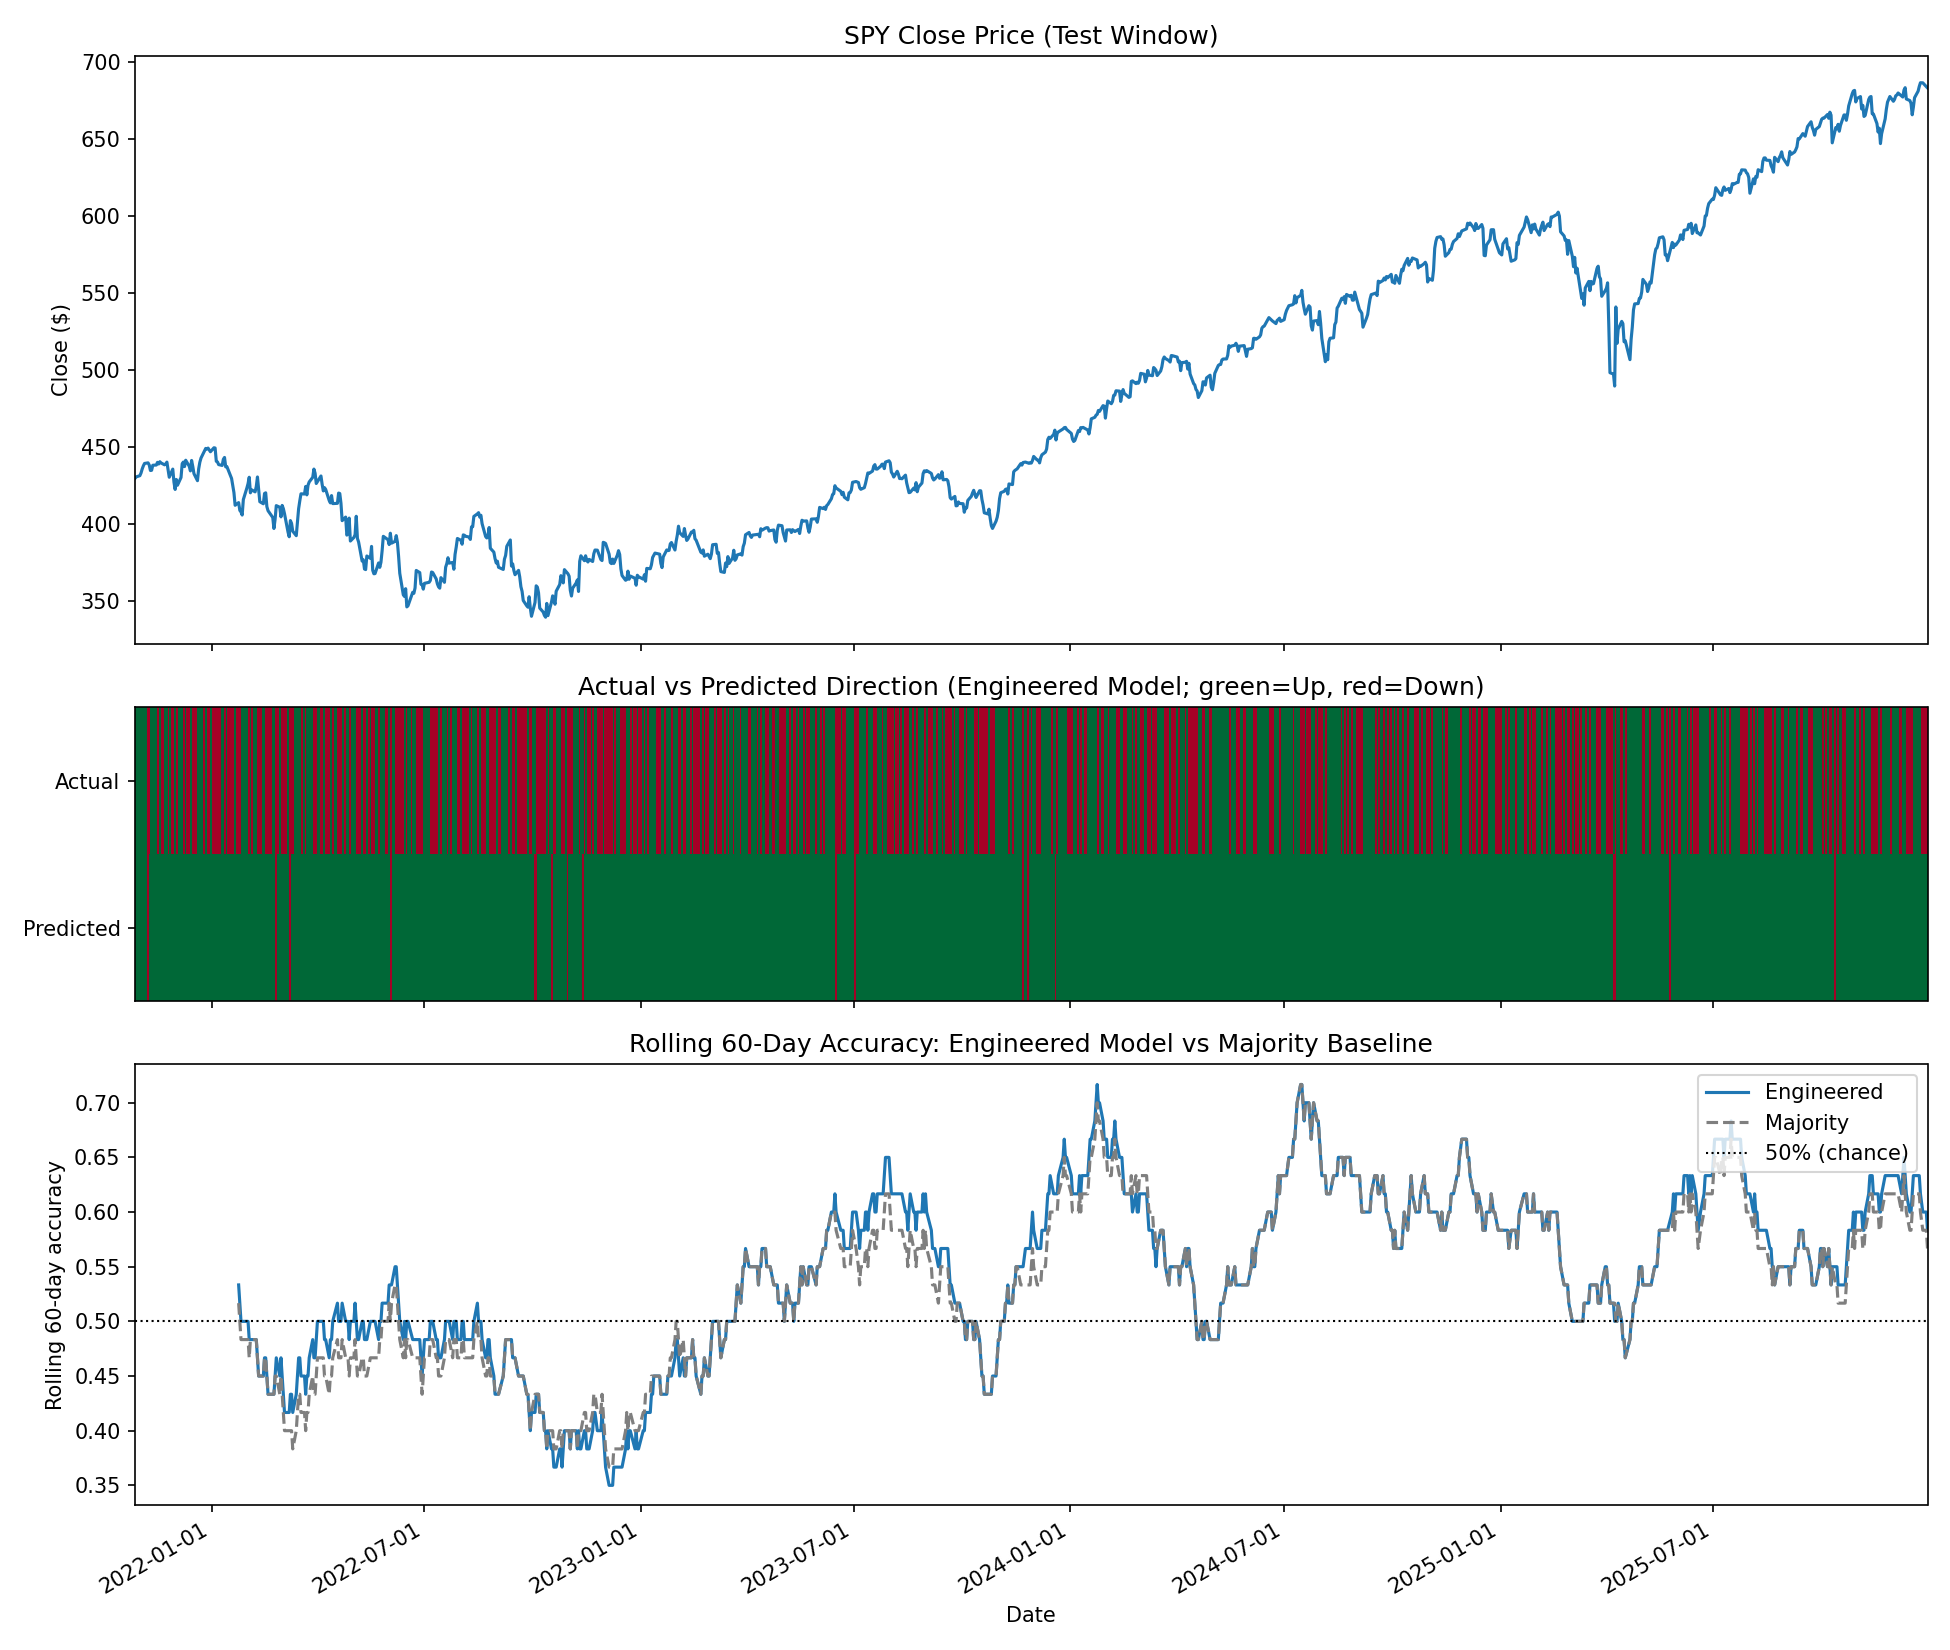

In [28]:
from src.evaluation import plot_predictions, plot_predictions_zoom

predictions_df = pd.DataFrame({
    "y_true": y_test,
    "persistence": pred_persistence,
    "majority": pred_majority,
    "raw": pred_raw,
    "engineered": pred_engineered,
})

predictions_png_path = plot_predictions(df["Close"], predictions_df)
print(f"Saved -> {predictions_png_path}")
from IPython.display import Image as _Image
_Image(filename=str(predictions_png_path))

Saved -> D:\PROJECTS\Stock-ml\outputs\predictions_zoom.png


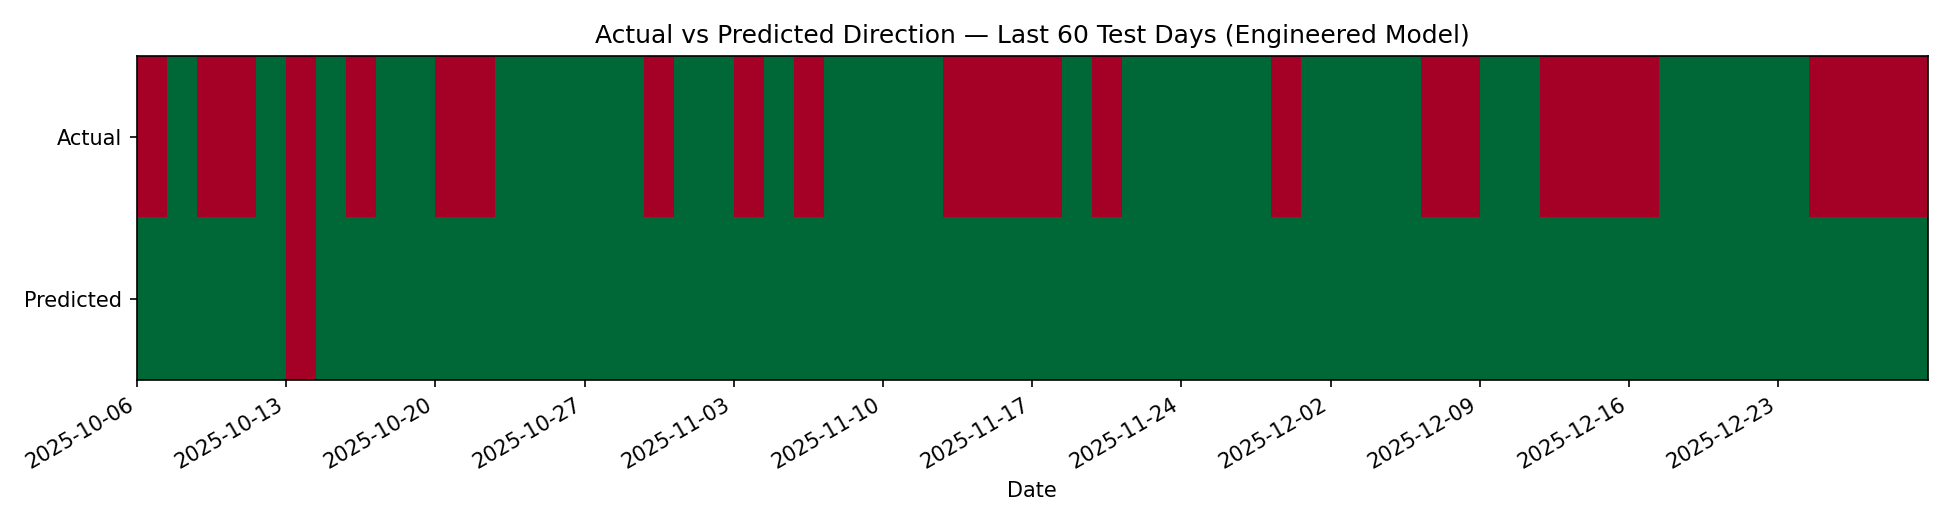

In [29]:
zoom_png_path = plot_predictions_zoom(predictions_df, n_days=60)
print(f"Saved -> {zoom_png_path}")
_Image(filename=str(zoom_png_path))

## 19. Analysis

- **All four approaches cluster tightly in the 49-55% range** on the held-out test set, and their 95% confidence
  intervals overlap heavily. There is no statistically clear winner from the single 80/20 split alone.
- **Persistence is the weakest approach** (~51% single-split, ~49.6% walk-forward mean) -- SPY daily direction does
  not meaningfully autocorrelate day-to-day, so "tomorrow = today" is close to a coin flip, slightly worse even.
- **Majority Class is a genuinely strong baseline** (~54-55%), simply because the test period (like the full
  history) has more Up days than Down days (~55% Up). Any model that doesn't clear this bar isn't adding value
  beyond the base rate.
- **Engineered features edge out raw features** by a small margin on the single split (54.8% vs 54.3% accuracy,
  50.9% vs 50.4% balanced accuracy) and are roughly tied with raw features in the walk-forward check (54.8% vs
  54.7% mean). This is a real but small improvement -- balanced accuracy for both is barely above 50%, meaning
  neither model separates the two classes much better than chance once the class imbalance is accounted for.
- **Neither logistic model decisively beats Majority Class**, in either the single split or the walk-forward check.
  The walk-forward mean actually ranks Majority Class (55.3%) slightly above Engineered (54.8%) and Raw (54.7%).
- **Honest interpretation:** with this feature set and a simple linear model, technical-indicator engineering does
  not produce a practically or statistically significant improvement over a naive base-rate baseline for next-day
  SPY direction. This is consistent with the efficient-market expectation that a liquid, heavily-traded index like
  SPY should not have easily exploitable linear structure in daily OHLCV-derived features. The experiment does its
  job: it rigorously tests the hypothesis and reports that the hypothesis (engineered features help) is not well
  supported by the evidence, rather than manufacturing a more flattering number.

## 20. Limitations

- **No transaction costs, slippage, or execution modeling** -- this is a classification accuracy study, not a
  trading strategy backtest. Nothing here should be read as evidence of a profitable strategy.
- **Single ticker (SPY), single asset class.** Results may not generalize to individual equities, other indices,
  or other timeframes (intraday, weekly).
- **Linear model only.** Logistic Regression cannot capture nonlinear interactions between features; a small
  improvement or no improvement here does not rule out engineered features being useful to a nonlinear model.
- **Small, fixed feature set (5 raw + 5 indicators).** Chosen deliberately per `PLAN.md` to avoid overfitting via
  feature search, but it also means the experiment cannot speak to indicators outside this set.
- **Walk-forward uses only 5 folds** -- more folds would tighten the mean/std estimates but were kept at 5 for
  a reasonably sized expanding window per fold.
- **No probability calibration or decision-threshold analysis** -- predictions use the default 0.5 threshold from
  `LogisticRegression.predict()`.
- **`auto_adjust=True` dividend/split adjustment** slightly changes historical price levels over a 21-year window;
  this affects absolute price-derived features negligibly (all features here are same-day ratios/differences, not
  raw price levels) but is worth noting for full transparency.

## 21. Conclusion

This notebook built a leakage-verified pipeline for next-day SPY direction prediction: causal, past-only features;
a target constructed and independently cross-checked to avoid a subtle NaN-casting bug; a strict chronological
80/20 split with a 1-row embargo; a scaler fit only on training data; and both a single-split and a walk-forward
evaluation across four approaches (Persistence, Majority Class, Raw Features, Engineered Features).

The honest result is that **technical-indicator feature engineering provides at most a marginal, not clearly
significant, improvement** over raw features and the majority-class baseline for this task, model, and feature set.
The real value of this project is in the rigor of the pipeline -- the explicit leakage checks, the naive baselines,
and the chronological + walk-forward evaluation methodology -- rather than in a headline accuracy number, which is
exactly what an honest time-series ML experiment on an efficient, liquid market should show.